# Session 1 — Introduction to Simulation & OSCM Applications

**Course:** Decision Modelling — Simulation Part
**Session:** 1 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Explain *why* simulation is used as a decision-support tool in Operations and Supply Chain Management (OSCM)
- Distinguish **Monte Carlo (MC) simulation** from **Discrete-Event Simulation (DES)**, and recognize which decision questions each is suited to
- Build a basic **conceptual model** of a simple operational system
- Interpret **WIP**, **Throughput (TH)**, and **Cycle Time (CT)** at a high, intuitive level (no formulas yet — that comes in Session 5)

## Where this session fits

- **Prerequisites:** basic Python only (covered in Advanced Data Analysis). No prior simulation experience is assumed.
- **Looking ahead:** today we build the vocabulary and mental models the rest of the course relies on. The random experiment at the end previews the idea of *randomness as something we can generate, observe, and reason about statistically* — which Session 2 (Modeling Randomness & Input Analysis) makes precise.
- **Looking sideways:** the mathematical-programming part of this course builds optimization models that *prescribe* a decision, often under simplifying assumptions (e.g., expected demand, no congestion). Simulation *evaluates* how a system behaves under uncertainty and operational complexity — including things an optimization model may assume away. We'll return to this relationship explicitly in the integration sessions later in the course.


## Further reading (supplementary, not required)

- A chapter from *Business Process Modeling, Simulation and Design* (2013) on simulation as a decision-support methodology in operations — check the course reading list / library for the specific chapter reference.

This course does not use a single required textbook for the simulation part. Each session points to focused supplementary readings rather than a fixed chapter sequence.


## 1. Why simulate?

Operations and supply chain decisions are made under **uncertainty** and **operational complexity**: random arrivals, variable service or processing times, limited capacity, and interactions between resources that are hard to capture in a closed-form equation.

Two broad families of analytical tools help with this:

- **Optimization** (the mathematical-programming part of this course) finds a *best* decision given an explicit mathematical representation of the problem — often built on simplifying assumptions (e.g. average demand, deterministic processing times).
- **Simulation** (this part of the course) *evaluates how a system behaves* when we relax those simplifying assumptions — introducing variability, congestion, and time-dynamics explicitly.

An optimized solution is not automatically robust. Simulation is how we stress-test it, and — later in the course — how we combine it with optimization to search for decisions that perform well *in practice*, not just on paper.

**Typical OSCM questions simulation helps answer:**

- How many service agents do we need to keep waiting times acceptable?
- What happens to inventory costs and stockout risk if demand is more volatile than expected?
- Where is the bottleneck in this production line, and how sensitive is throughput to it?
- If we changed this routing/scheduling policy, what would actually happen — on average, and in the worst case?


## 2. Types of systems and models

Before simulating anything, it helps to classify the system we're modeling along a few dimensions:

| Dimension | Options | Example |
|---|---|---|
| **State changes** | Discrete (jumps at specific points) vs. Continuous | A customer arriving (discrete) vs. water level in a tank (continuous) |
| **Randomness** | Deterministic vs. Stochastic | A fixed production schedule vs. random customer arrivals |
| **Time behavior** | Static ("one-shot") vs. Dynamic (evolves over time) | A single newsvendor order decision vs. a queue evolving all day |

This course focuses on systems that are **discrete-state** and **stochastic**. Within that space, we'll use two complementary simulation paradigms — introduced next.


## 3. Two simulation paradigms in this course

| | **Monte Carlo (MC) Simulation** | **Discrete-Event Simulation (DES)** |
|---|---|---|
| **Core idea** | Repeatedly sample random inputs and observe the resulting outputs | Model a system as it evolves over time, driven by discrete events (arrivals, service completions, etc.) |
| **Time** | Usually no explicit notion of time — each replication is a "one-shot" outcome | Explicit simulated clock; entities and resources interact over time |
| **Good for** | Decisions under uncertainty with a fixed structure: risk analysis, one-off decisions, propagating uncertainty through a formula or model | Systems with queues, resource contention, congestion, and dynamics that unfold over time |
| **Course example (later sessions)** | Newsvendor problem: how much to order given uncertain demand | A service system or production line: how do queues, utilization, and cycle times evolve as customers/jobs flow through |
| **Tooling in this course** | NumPy / SciPy | SimPy |

Both rely on the same underlying idea — using random numbers to represent uncertainty — but they answer different *kinds* of questions. Part of the skill you'll build in this course is recognizing **which paradigm fits a given decision problem**, which is exactly what Session 3 (MC) and Sessions 6–7 (DES) will let you practice.


## 4. Conceptual modeling

Before writing any code, a good simulation study starts with a **conceptual model** — a description of the system in words/diagrams that identifies:

- **System boundary** — what's inside the model, what's outside
- **Entities** — the "things" that flow through the system (customers, orders, jobs, parts)
- **Attributes** — properties attached to entities (e.g. a customer's arrival time, an order's priority)
- **Resources** — the capacity that entities compete for (servers, machines, staff)
- **Activities / events** — things that happen and change the system's state (an arrival, a service start, a service completion, a departure)
- **State variables** — quantities that describe the system at any point in time (number waiting, number in service)

**Example — a simple walk-in clinic:**

```
[Arrival] --> [Waiting room, queue] --> [Consultation with doctor] --> [Departure]
                     |                          |
              state: # waiting            state: doctor busy/idle
```

Entity: patient. Attributes: arrival time, urgency. Resource: doctor(s). Events: arrival, start of consultation, end of consultation.

This is exactly the kind of system we'll build in SimPy starting in Session 6 — today we only need to be comfortable *describing* it this way.


## 5. High-level performance measures: WIP, TH, CT

Three measures come up constantly when analyzing flow systems like the clinic example above:

- **WIP (Work-in-Process)** — how many entities are currently "in" the system (waiting + being served)
- **TH (Throughput)** — the rate at which entities complete and leave the system (e.g. patients served per hour)
- **CT (Cycle Time / Flow Time)** — how long a single entity spends in the system from arrival to departure

These three are connected by a simple and famous relationship — **Little's Law**: *WIP = TH × CT*. We are **not** deriving or proving this today; Session 4 covers it rigorously, once we've built more comfort with randomness (Sessions 2–3). For now, just build the intuition: if a clinic's patient queue is growing (WIP increasing) while throughput stays flat, cycle time for patients must be getting longer too — the three move together.


## 6. Hands-on: your first random experiment

Before building any simulation model, we need to be comfortable generating and reasoning about randomness in Python. This warm-up has nothing to do with OSCM yet — it's purely about building intuition for what "random" looks like when you simulate it many times.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)

# Simulate rolling a fair six-sided die many times
n_rolls = 1000
rolls = [random.randint(1, 6) for _ in range(n_rolls)]

print(f"First 10 rolls: {rolls[:10]}")
print(f"Average of {n_rolls} rolls: {np.mean(rolls):.3f}")
print(f"Theoretical average of a fair die: {3.5}")


First 10 rolls: [6, 1, 1, 6, 3, 2, 2, 2, 6, 1]
Average of 1000 rolls: 3.506
Theoretical average of a fair die: 3.5


Notice the sample average is close to, but not exactly, the theoretical value of 3.5. This is the essence of **Monte Carlo thinking**: any *single* run gives you a noisy estimate, but as you accumulate more trials, the average settles down toward the true underlying value. This is the **Law of Large Numbers**, and it's the statistical bedrock Session 3's Monte Carlo modeling is built on.

Let's watch this convergence happen.


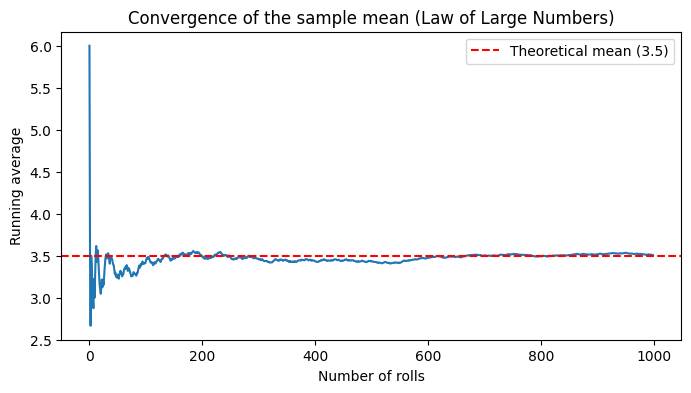

In [2]:
running_avg = np.cumsum(rolls) / np.arange(1, n_rolls + 1)

plt.figure(figsize=(8, 4))
plt.plot(running_avg)
plt.axhline(3.5, color='red', linestyle='--', label='Theoretical mean (3.5)')
plt.xlabel('Number of rolls')
plt.ylabel('Running average')
plt.title('Convergence of the sample mean (Law of Large Numbers)')
plt.legend()
plt.show()


### Exercise (guided): a simple random arrival process

A small coffee shop is open for 60 minutes. In each 1-minute interval, a customer arrives independently with probability `p = 0.3` (and no more than one customer arrives per minute — a simplification we'll relax later in the course).

Your task:

1. Simulate **one day** (60 one-minute intervals) and count how many customers arrived.
2. Repeat the simulation for **1000 days**, storing each day's customer count.
3. Plot a histogram of the daily customer counts.
4. Compute the mean and standard deviation of daily arrivals across the 1000 simulated days.

Fill in the `# TODO` lines below.


In [3]:
# EXERCISE
random.seed(1)

p = 0.3
minutes = 60
n_days = 1000

daily_counts = []

for day in range(n_days):
    arrivals = None  # TODO: simulate `minutes` Bernoulli(p) trials and sum them
    daily_counts.append(arrivals)

# TODO: plot a histogram of daily_counts

# TODO: print the mean and standard deviation of daily_counts


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
random.seed(1)

p = 0.3
minutes = 60
n_days = 1000

daily_counts = []

for day in range(n_days):
    arrivals = sum(1 for _ in range(minutes) if random.random() < p)
    daily_counts.append(arrivals)

plt.figure(figsize=(8, 4))
plt.hist(daily_counts, bins=range(min(daily_counts), max(daily_counts) + 2), edgecolor='black')
plt.xlabel('Customers arriving in a day')
plt.ylabel('Number of simulated days')
plt.title('Distribution of daily arrivals (1000 simulated days)')
plt.show()

print(f"Mean daily arrivals: {np.mean(daily_counts):.2f}")
print(f"Std dev of daily arrivals: {np.std(daily_counts):.2f}")
print(f"Expected value (n x p): {minutes * p}")
```
</details>


### Discussion questions

1. The expected number of daily arrivals is `minutes × p = 18`. Was your simulated mean close to this? Would you expect it to be *exactly* 18? Why or why not?
2. Suppose the coffee shop owner wants to know: "what's the chance we get more than 25 customers in a day?" How could you answer this directly from `daily_counts`, without deriving any formula?
3. This model treats each minute independently with a fixed arrival probability. What real features of customer arrivals might this be missing (think about lunch rushes, weekends, etc.)? We'll address this properly in Session 2 (input analysis) when we fit real arrival data.
4. Right now we only tracked "how many arrived." We didn't model what happens to them next (a queue, a barista, waiting). Why do you think that requires a different kind of simulation than what we did today? (Keep this in mind — it's exactly why DES exists, starting Session 6.)


## Wrap-up

Today we:

- Motivated simulation as a decision-support tool that complements optimization by evaluating uncertainty and operational complexity
- Distinguished Monte Carlo simulation from Discrete-Event Simulation, and previewed which OSCM questions each is suited to
- Introduced conceptual modeling vocabulary (entities, attributes, resources, events, state variables)
- Introduced WIP, TH, and CT intuitively (full treatment in Session 5)
- Ran our first random experiment in Python and observed the Law of Large Numbers in action

**Next session:** Modeling Randomness & Input Analysis — we'll move from "randomness in general" to fitting distributions to real data, so that the random inputs we simulate actually represent the system we're studying.
